# Statistical Learning

# Introduction to Statistical Learning

What is Statistical Learning?

A set of tools and math techniques to **understand data** and **make predictions**.

## 1. Inputs and Output

We want to predict an output \(Y\) using input features \(X\).

Example: predicting **Sales** using advertising:

$$
X_1=\text{TV},\qquad
X_2=\text{Radio},\qquad
X_3=\text{Newspaper}
$$

The entire input vector is:

$$
\boxed{
X=
\begin{bmatrix}
X_1\\
X_2\\
X_3
\end{bmatrix}}
$$

* \(X\) = all input variables together
* \(X_1,X_2,X_3\) = individual input variables
* \(Y\) = output/random variable

---

## 2. Capital vs. Small Letters

**Capital letters = random variables / general variables**

$$
X=(X_1,X_2,X_3)
$$

**Small letters = specific observed values**

For one campaign:

$$
x=
\begin{bmatrix}
x_1\\x_2\\x_3
\end{bmatrix}
=
\begin{bmatrix}
100\\50\\20
\end{bmatrix}
$$

So:

$$
X_1\rightarrow x_1=100
$$

$$
X_2\rightarrow x_2=50
$$

$$
X_3\rightarrow x_3=20
$$

And:

$$
X\rightarrow x=
\begin{bmatrix}
100\\50\\20
\end{bmatrix}
$$

**Think:**

> \(X\) = the variable in general
> \(x\) = one particular value/observation

---


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible random data
np.random.seed(42)

# Number of marketing campaigns
n = 200

# Input features
tv = np.random.uniform(0, 300, n)
radio = np.random.uniform(0, 50, n)
newspaper = np.random.uniform(0, 100, n)

# Random noise (epsilon)
epsilon = np.random.normal(0, 2, n)

# Output variable
# This is the unknown relationship f(X) + epsilon
sales = (
        3
        + 0.05 * tv
        + 0.15 * radio
        + 0.01 * newspaper
        + epsilon
)

# Create dataset
df = pd.DataFrame({
    "TV": tv,
    "Radio": radio,
    "Newspaper": newspaper,
    "Sales": sales
})


,TV,Radio,Newspaper,Sales
0,112.362036,32.101582,10.312387,12.475948
1,285.214292,4.206998,90.255291,17.208572
2,219.598183,8.081436,50.525237,15.483316
3,179.597545,44.927709,82.645747,17.475006
4,46.805592,30.321453,32.004960,9.101249


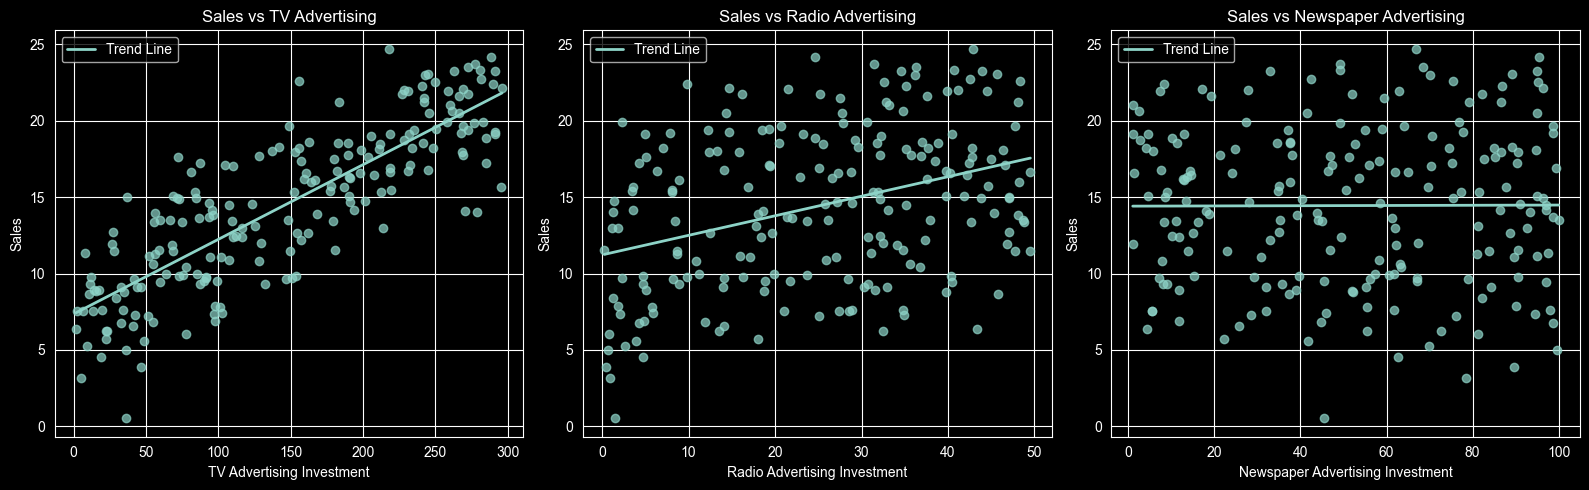

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ["TV", "Radio", "Newspaper"]

for ax, feature in zip(axes, features):
    # Scatter plot
    ax.scatter(
        df[feature],
        df["Sales"],
        alpha=0.7
    )

    # Calculate linear trend line
    slope, intercept = np.polyfit(
        df[feature],
        df["Sales"],
        1
    )

    # Generate x values for the line
    x_values = np.linspace(
        df[feature].min(),
        df[feature].max(),
        100
    )

    # Calculate corresponding y values
    y_values = slope * x_values + intercept

    # Plot trend line
    ax.plot(
        x_values,
        y_values,
        linewidth=2,
        label="Trend Line"
    )

    # Labels
    ax.set_title(f"Sales vs {feature} Advertising")
    ax.set_xlabel(f"{feature} Advertising Investment")
    ax.set_ylabel("Sales")
    ax.legend()

plt.tight_layout()
plt.show()

### 3. 200 Observations

If we have 200 campaigns, we still only have 3 input variables:

$$
X_1,X_2,X_3
$$

But we observe them 200 times:

$$
x^{(1)},x^{(2)},...,x^{(200)}
$$

Each observation is a 3-dimensional vector:

$$
x^{(i)}=
\begin{bmatrix}
x_1^{(i)}\\
x_2^{(i)}\\
x_3^{(i)}
\end{bmatrix}
$$

So:

$$
\boxed{3\text{ features}\times200\text{ observations}}
$$

---

# 4. Additive Model

The basic model is:

$$
\boxed{Y=f(X)+\epsilon}
$$

Meaning:

$$
\boxed{
\text{Actual output}
=
\text{underlying relationship}
+
\text{random noise}
}
$$

### \(f(X)\)

\(f\) = unknown **regression function**.

It represents the systematic relationship between inputs and output.

$$
f(X)=\text{what the inputs explain}
$$

### \(\epsilon\)

$$
\epsilon=\text{random error/noise}
$$

It represents things affecting \(Y\) that aren't captured by \(X\).

Examples:

* weather
* competitors
* customer behavior
* random events
* measurement error

---

## 5. Expected Error

We assume:

$$
\boxed{E[\epsilon]=0}
$$

This does **NOT** mean every error is zero.

It means:

> Errors are centered around zero and, on average, don't systematically push predictions up or down.

Example:

$$
+10,-10,+5,-5
$$

Average:

$$
E[\epsilon]\approx0
$$

So the model isn't systematically overpredicting or underpredicting.

---

## 6. Variance of the Error

We also assume:

$$
\boxed{Var(\epsilon)=\sigma^2}
$$

Variance tells us how much the random errors **spread around zero**.

Because:

$$
E[\epsilon]=0
$$

we have:

$$
\boxed{Var(\epsilon)=E[\epsilon^2]=\sigma^2}
$$

So:

* \(E[\epsilon]\) → **direction/bias of error**
* \(Var(\epsilon)\) → **spread/size of random error**

---

## 7. MSE

For observed data, we calculate residuals:

$$
e_i=y_i-\hat f(x_i)
$$

MSE:

$$
\boxed{
MSE=\frac{1}{n}\sum_{i=1}^{n}e_i^2
}
$$

MSE tells us:

> **How large our prediction errors are, regardless of whether they are positive or negative.**

Because squaring makes:

$$
(+10)^2=(-10)^2=100
$$

---

## 8. Two Different Questions

When evaluating a model:

### Question 1:

**"Am I systematically too high or too low?"**

Look at:

$$
\boxed{\text{Average error}\approx0}
$$

### Question 2:

**"How far off are my predictions?"**

Look at:

$$
\boxed{MSE}
$$

Ideally:

$$
\boxed{
\text{Average error}\approx0
\quad\text{AND}\quad
MSE\text{ is small}
}
$$

---

## 9. Big Picture

$$
\boxed{
Y=f(X)+\epsilon
}
$$

Think:

$$
\underbrace{Y}_{\text{what actually happens}}
=
\underbrace{f(X)}_{\text{what inputs explain}}
+
\underbrace{\epsilon}_{\text{random/unexplained part}}
$$

The goal of statistical learning is to use historical data to estimate the unknown function:

$$
\boxed{f(X)\rightarrow\hat f(X)}
$$

so that we can make good predictions for new \(x\)'s.
